# Import Library

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os, sys

# Constantes

In [2]:
IMAGE_WIDTH=224
IMAGE_HEIGHT=224
IMAGE_CHANNELS=3
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)
BATCH_SIZE = 32
EPOCHS = 100

# Preparar los datos

In [3]:
# Añadir la raíz del proyecto al path
ROOT_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT_PATH not in sys.path:
    sys.path.append(ROOT_PATH)
    
TRAIN_PATH = ROOT_PATH+ '/data/train/'
TEST_PATH = ROOT_PATH + '/data/test/'

CATEGORIES = ['sin-cara', 'cara']

In [4]:
# Listar todos los archivos de la carpeta de train (TRAIN_PATH)
filenames_cara = os.listdir(TRAIN_PATH + 'cara')
filenames_sincara = os.listdir(TRAIN_PATH + 'sin-cara')
filenames = filenames_cara + filenames_sincara

# Lista vacia
categories = []

# Iterar
for filename in filenames:
    # Saco el nombre
    category = filename.split('_')[0]

    # Guardo en lista
    if category == 'cara':
        categories.append(1)
    else:
        categories.append(0)
    
    
df = pd.DataFrame({
    'filename': filenames,
    'category': categories
}) 

In [5]:
df

,filename,category
0,cara_009.jpg,1
1,cara_010.png,1
2,cara_024.jpg,1
3,cara_025.jpeg,1
4,cara_033.jpg,1
...,...,...
873,sin-cara_995.jpeg,0
874,sin-cara_996.jpeg,0
875,sin-cara_997.jpeg,0
876,sin-cara_998.jpeg,0


In [6]:
category_to_id = {cat: i for i, cat in enumerate(CATEGORIES)}

# Lista donde guardaremos los registros
data = []

for category in CATEGORIES:
    folder_path = os.path.join(TRAIN_PATH, category)
    
    for file in os.listdir(folder_path):
        if file.lower().endswith(('.jpeg', '.jpg', '.png')):
            
            new_filename = f'{file}'
            
            data.append({
                'filename': new_filename,
                'category': category_to_id[category]
            })

# Convertimos a DataFrame
df = pd.DataFrame(data)

df

,filename,category
0,sin-cara_002.jpeg,0
1,sin-cara_010.jpg,0
2,sin-cara_011.jpg,0
3,sin-cara_012.png,0
4,sin-cara_013.png,0
...,...,...
873,cara_518.jpeg,1
874,cara_519.jpeg,1
875,cara_520.jpeg,1
876,cara_521.jpeg,1


Visualizamos una imagen de cada categoría.

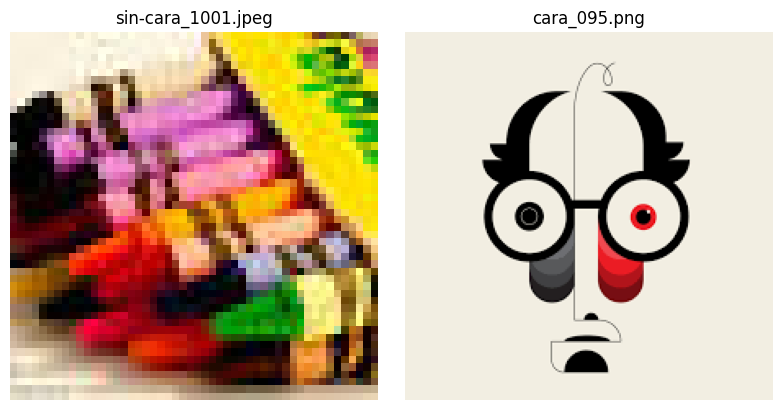

In [7]:
from skimage.io import imread

plt.figure(figsize=(12, 8))

for i, category in enumerate(CATEGORIES):
    
    folder_path = os.path.join(TRAIN_PATH, category)
    
    filenames = [f for f in os.listdir(folder_path)]
    
    sample = random.choice(filenames)
    
    image = imread(os.path.join(folder_path, sample))
    
    # Visualización
    plt.subplot(2, 3, i+1)
    plt.imshow(image)
    plt.title(f'{sample}')
    plt.axis('off')

plt.tight_layout()

# Resize de las imágenes

Tamaño imagen original: (290, 174, 3)
Tamaño imagen reshape: (224, 224, 3)


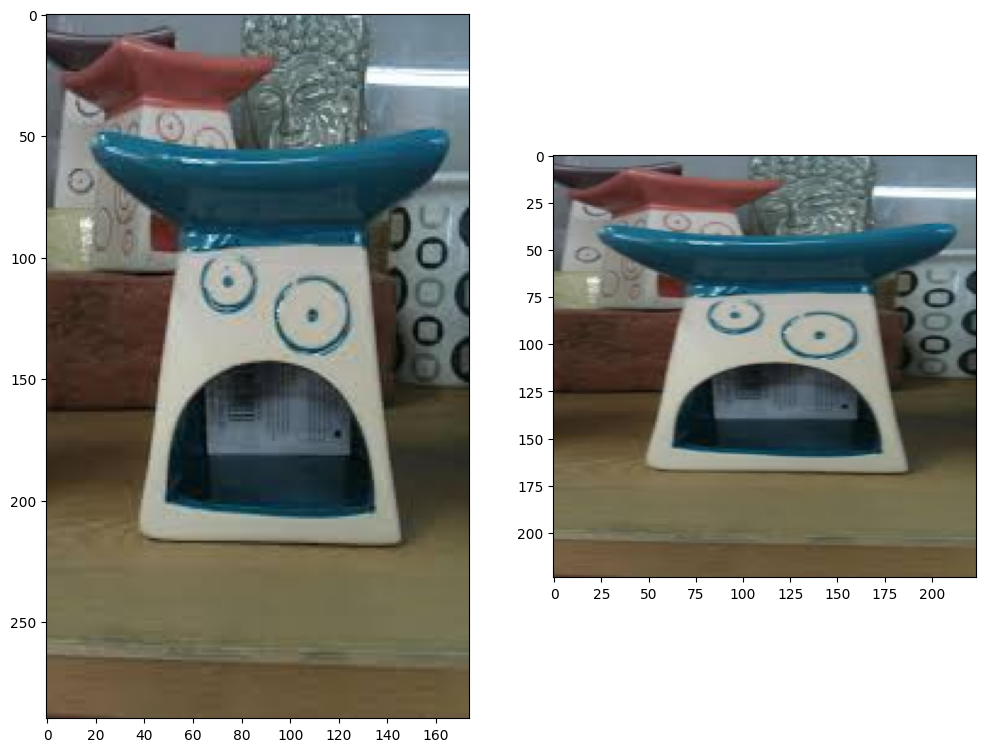

In [8]:
from skimage.io import imread
import cv2

plt.figure(figsize=(12, 12))

sample = random.choice(filenames)
# sample = 'sin-cara_008.jpg'
ctgry = sample.split('_')[0] + '/'
image = imread(TRAIN_PATH + ctgry + sample)
imagesmall = cv2.resize(image, (IMAGE_WIDTH, IMAGE_HEIGHT))

print('Tamaño imagen original:', image.shape)
print('Tamaño imagen reshape:', imagesmall.shape)

# Original image
plt.subplot(1, 2, 1)
plt.imshow(image)

# Resized image
plt.subplot(1, 2, 2)
plt.imshow(imagesmall);

# Cargar datos

In [9]:
# Función para cargar imágenes
import cv2

def read_data(ruta):
    X = []
    Y = []
    
    for c, cat in enumerate(CATEGORIES):
        path = ruta + cat + '/'
    
        # Iterar sobre todo lo que haya en path
        for file in os.listdir(path):
            
            # Leer la imagen a color y aplicarle el resize
            image = imread(path + file)
            print(file)
            smallimage = cv2.resize(image, (IMAGE_WIDTH, IMAGE_HEIGHT))
            
            # Comprobación: detectar shapes inesperados
            if smallimage.shape != (IMAGE_WIDTH, IMAGE_HEIGHT, 3):
                print(f'Shape inesperado {smallimage.shape} → {path + file}')
                continue
            
            # Guardo en X
            X.append(smallimage)
            Y.append(c)

    return np.array(X), np.array(Y)

In [10]:
X_train, y_train = read_data(TRAIN_PATH)
X_test, y_test = read_data(TEST_PATH)

print(X_train.shape)
print(X_test.shape)

sin-cara_002.jpeg
sin-cara_010.jpg
sin-cara_011.jpg
sin-cara_012.png
sin-cara_013.png
sin-cara_020.jpg
sin-cara_021.png
sin-cara_023.jpg
sin-cara_024.jpeg
sin-cara_026.jpg
sin-cara_027.jpg
sin-cara_027.png
sin-cara_028.jpeg
sin-cara_031.jpg
sin-cara_032.png
sin-cara_045.jpg
sin-cara_046.jpg
sin-cara_047.jpg
sin-cara_048.jpg
sin-cara_049.jpg
sin-cara_050.jpg
sin-cara_051.jpg
sin-cara_052.jpg
sin-cara_053.jpg
sin-cara_054.jpg
sin-cara_055.jpg
sin-cara_056.jpg
sin-cara_057.jpg
sin-cara_058.jpg
sin-cara_059.jpg
sin-cara_060.jpg
sin-cara_061.jpg
sin-cara_062.jpg
sin-cara_063.jpg
sin-cara_064.jpg
sin-cara_065.jpg
sin-cara_066.jpg
sin-cara_067.jpg
sin-cara_068.jpg
sin-cara_069.jpg
sin-cara_070.jpg
sin-cara_071.jpg
sin-cara_072.jpg
sin-cara_073.jpg
sin-cara_078.jpeg
sin-cara_079.jpeg
sin-cara_080.jpeg
sin-cara_081.jpeg
sin-cara_082.jpeg
sin-cara_083.jpeg
sin-cara_084.jpeg
sin-cara_085.jpeg
sin-cara_086.jpeg
sin-cara_087.jpeg
sin-cara_088.jpeg
sin-cara_089.jpg
sin-cara_090.jpeg
sin-cara_090.jpg

c:\Users\NitroPC\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


sin-cara_007.png
sin-cara_008.png
Shape inesperado (224, 224, 4) → c:\Users\NitroPC\OneDrive\Documentos\GIT\Pareidolia_ML/data/test/sin-cara/sin-cara_008.png
sin-cara_009.jpeg
sin-cara_009.jpg
sin-cara_010.jpeg
sin-cara_010.jpg
sin-cara_011.jpeg
sin-cara_012.jpeg
sin-cara_013.jpeg
sin-cara_014.jpeg
sin-cara_015.jpeg
sin-cara_016.jpeg
sin-cara_017.jpeg
sin-cara_018.jpeg
sin-cara_019.jpeg
sin-cara_020.jpeg
sin-cara_021.jpeg
sin-cara_022.jpeg
sin-cara_023.jpeg
sin-cara_024.jpeg
sin-cara_025.jpeg
sin-cara_026.jpeg
sin-cara_027.jpeg
sin-cara_028.jpeg
sin-cara_029.jpeg
sin-cara_030.jpeg
sin-cara_031.jpeg
sin-cara_032.jpeg
sin-cara_033.jpeg
sin-cara_034.jpeg
sin-cara_035.jpeg
sin-cara_036.jpeg
sin-cara_037.jpeg
sin-cara_038.jpeg
sin-cara_039.jpeg
sin-cara_040.jpeg
sin-cara_041.jpeg
sin-cara_042.jpeg
sin-cara_043.jpeg
sin-cara_044.jpeg
sin-cara_045.jpeg
sin-cara_046.jpeg
sin-cara_047.jpeg
sin-cara_048.jpeg
sin-cara_049.jpeg
sin-cara_050.jpeg
sin-cara_051.jpeg
sin-cara_052.jpeg
sin-cara_053.jpe

# Normalizamos data

In [11]:
print('Min:', np.min(X_train))
print('Max:', np.max(X_train))

Min: 0
Max: 255


In [12]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print('Min:', np.min(X_train))
print('Max:', np.max(X_train))

Min: 0.0
Max: 1.0


# Preparamos data para modelo

In [13]:
# Mezclamos imágenes para que no salgan en orden
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train, y_train, random_state=42)

Guardamos los arrays de numpy en un archivo `.npz`, de tal manera que luego sea más rápido importarlo.

In [14]:
np.savez(ROOT_PATH + '/data/data.npz',
        X_train = X_train,
        y_train = y_train,
        X_test = X_test,
        y_test = y_test)

Cargar data

In [15]:
# Cargar data
data = np.load(ROOT_PATH + '/data/data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# Construimos modelos

Ranking de modelos preentrenados para nuestro proyecto de pareidolia


Para este experimento probaremos varios backbones de visión por computador y los compararemos en igualdad de condiciones. El ranking está basado en su rendimiento típico en transfer learning con datasets pequeños, su eficiencia y su capacidad para capturar patrones relevantes en pareidolia (simetrías, texturas y formas globales).

1. **EfficientNetB0**  
Modelo ligero y muy eficiente. Suele ofrecer el mejor equilibrio entre precisión, velocidad y generalización en datasets pequeños. Será nuestro baseline principal.

2. **ResNet-50**  
Arquitectura robusta y estable, excelente para transfer learning. Ideal como segundo candidato para comparar contra EfficientNetB0.

3. **Xception**  
Especialmente bueno captando texturas y patrones locales. Requiere imágenes de mayor tamaño (299×299), pero puede aportar una perspectiva distinta.

4. **InceptionV3**  
Potente, aunque menos eficiente que Xception y EfficientNet en este tipo de tareas. Lo probaremos solo si buscamos ampliar comparativas.

5. **VGG-16 / VGG-19**  
Modelos muy pesados y propensos al sobreajuste. Se incluyen únicamente como referencia histórica, no como opciones óptimas.

Definimos funciones

In [16]:
from tensorflow.keras.applications import EfficientNetB0, ResNet50, Xception, InceptionV3, VGG16
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Función para construir modelos
def build_model(backbone_fn, input_shape=(224, 224, 3), weights='imagenet'):
    base = backbone_fn(include_top=False, weights=weights, input_shape=input_shape)
    base.trainable = False  # congelamos el backbone

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')  # salida binaria
    ])

    model.compile(
        optimizer=optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# Función para entrenar los modelos
def train_model(model, X_train, y_train, epochs=30, batch_size=32):
    cb = [
        callbacks.EarlyStopping(patience=7, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ]
    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=1
    )
    return history


# Función para evaluar modelo
def evaluate_model(name, model, history, X_test, y_test):
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(classification_report(y_test, y_pred, target_names=['sin_cara', 'cara']))

    auc = roc_auc_score(y_test, y_prob)
    print(f'AUC-ROC: {auc:.4f}')

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].imshow(cm, cmap='Blues')
    axes[0].set_title(f'{name} — Matriz de confusión')
    axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14)
    axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
    axes[0].set_xticklabels(['sin_cara','cara']); axes[0].set_yticklabels(['sin_cara','cara'])

    # Curvas de aprendizaje
    axes[1].plot(history.history['accuracy'], label='Train acc')
    axes[1].plot(history.history['val_accuracy'], label='Val acc')
    axes[1].set_title(f'{name} — Curvas de aprendizaje')
    axes[1].set_xlabel('Época'); axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {'name': name, 'auc': auc, 'y_prob': y_prob,
            'acc': (y_pred == y_test).mean(), 'model': model}


# Función para predecir imagen nueva
def predict_image(model, image_path):
    from PIL import Image
    img = Image.open(image_path).convert('RGB').resize((IMAGE_WIDTH, IMAGE_HEIGHT))
    arr = np.array(img).astype(np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)

    prob = model.predict(arr, verbose=0)[0][0]
    label = 'cara' if prob >= 0.5 else 'sin_cara'

    plt.imshow(np.array(img))
    plt.title(f'{label}  (confianza: {prob:.2%})')
    plt.axis('off'); plt.show()

    return label, prob


Entrenamos modelos 'EfficientNetB0', 'ResNet50' y 'Xception'


>>> Entrenando EfficientNetB0...
Epoch 1/30
24/24 [==============================] - 37s 1s/step - loss: 0.7091 - accuracy: 0.5523 - val_loss: 0.6631 - val_accuracy: 0.6894 - lr: 1.0000e-04
Epoch 2/30
24/24 [==============================] - 26s 1s/step - loss: 0.6826 - accuracy: 0.5979 - val_loss: 0.6615 - val_accuracy: 0.6894 - lr: 1.0000e-04
Epoch 3/30
24/24 [==============================] - 26s 1s/step - loss: 0.6928 - accuracy: 0.6180 - val_loss: 0.6552 - val_accuracy: 0.6894 - lr: 1.0000e-04
Epoch 4/30
24/24 [==============================] - 27s 1s/step - loss: 0.6743 - accuracy: 0.6072 - val_loss: 0.6668 - val_accuracy: 0.6894 - lr: 1.0000e-04
Epoch 5/30
24/24 [==============================] - 27s 1s/step - loss: 0.6984 - accuracy: 0.5871 - val_loss: 0.6609 - val_accuracy: 0.6894 - lr: 1.0000e-04
Epoch 6/30
24/24 [==============================] - ETA: 0s - loss: 0.6982 - accuracy: 0.5965
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
24/24 [====

c:\Users\NitroPC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NitroPC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NitroPC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

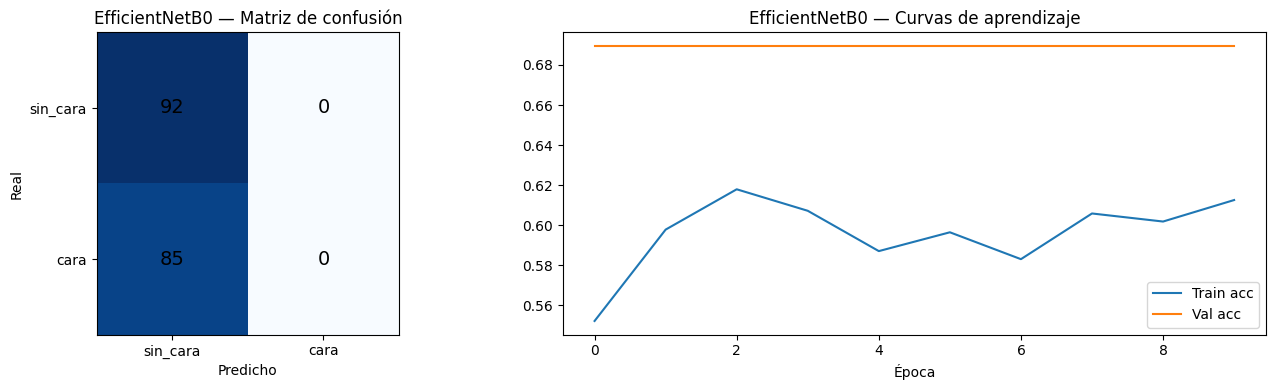


>>> Entrenando ResNet50...
Epoch 1/30
24/24 [==============================] - 50s 2s/step - loss: 0.7212 - accuracy: 0.5416 - val_loss: 0.7855 - val_accuracy: 0.3106 - lr: 1.0000e-04
Epoch 2/30
24/24 [==============================] - 45s 2s/step - loss: 0.6577 - accuracy: 0.5979 - val_loss: 0.7363 - val_accuracy: 0.3561 - lr: 1.0000e-04
Epoch 3/30
24/24 [==============================] - 43s 2s/step - loss: 0.6318 - accuracy: 0.6475 - val_loss: 0.7105 - val_accuracy: 0.3864 - lr: 1.0000e-04
Epoch 4/30
24/24 [==============================] - 41s 2s/step - loss: 0.5971 - accuracy: 0.6756 - val_loss: 0.6959 - val_accuracy: 0.5152 - lr: 1.0000e-04
Epoch 5/30
24/24 [==============================] - 42s 2s/step - loss: 0.5862 - accuracy: 0.6863 - val_loss: 0.6881 - val_accuracy: 0.5985 - lr: 1.0000e-04
Epoch 6/30
24/24 [==============================] - 43s 2s/step - loss: 0.5616 - accuracy: 0.7064 - val_loss: 0.6776 - val_accuracy: 0.5985 - lr: 1.0000e-04
Epoch 7/30
24/24 [============

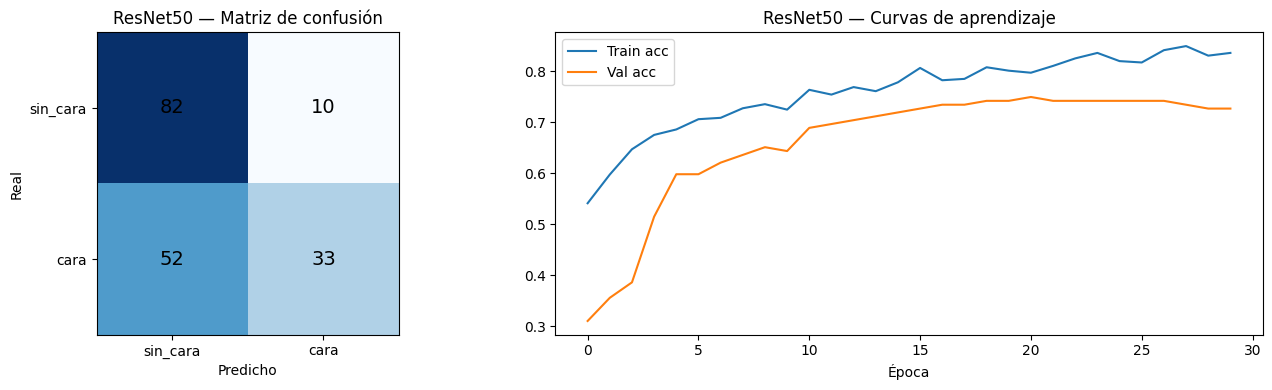


>>> Entrenando Xception...
Epoch 1/30
24/24 [==============================] - 67s 3s/step - loss: 0.8720 - accuracy: 0.5523 - val_loss: 0.6569 - val_accuracy: 0.6288 - lr: 1.0000e-04
Epoch 2/30
24/24 [==============================] - 69s 3s/step - loss: 0.5701 - accuracy: 0.7131 - val_loss: 0.6062 - val_accuracy: 0.7273 - lr: 1.0000e-04
Epoch 3/30
24/24 [==============================] - 68s 3s/step - loss: 0.4114 - accuracy: 0.8137 - val_loss: 0.5447 - val_accuracy: 0.8258 - lr: 1.0000e-04
Epoch 4/30
24/24 [==============================] - 68s 3s/step - loss: 0.3267 - accuracy: 0.8686 - val_loss: 0.5087 - val_accuracy: 0.8636 - lr: 1.0000e-04
Epoch 5/30
24/24 [==============================] - 69s 3s/step - loss: 0.2691 - accuracy: 0.8874 - val_loss: 0.4714 - val_accuracy: 0.8864 - lr: 1.0000e-04
Epoch 6/30
24/24 [==============================] - 67s 3s/step - loss: 0.2420 - accuracy: 0.9008 - val_loss: 0.4366 - val_accuracy: 0.8864 - lr: 1.0000e-04
Epoch 7/30
24/24 [============

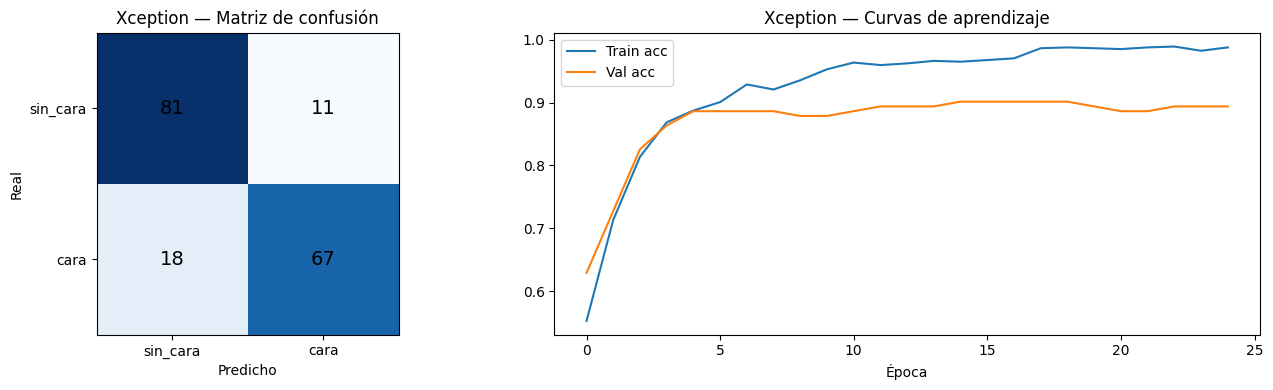

In [17]:
X_train_xception = tf.image.resize(X_train, [299, 299]).numpy()
X_test_xception  = tf.image.resize(X_test,  [299, 299]).numpy()

BACKBONES = {
    'EfficientNetB0': (EfficientNetB0, (224, 224, 3), X_train,         X_test),
    'ResNet50':       (ResNet50,       (224, 224, 3), X_train,         X_test),
    'Xception':       (Xception,       (299, 299, 3), X_train_xception, X_test_xception)
}

results = []

for name, (backbone_fn, input_shape, X_tr, X_te) in BACKBONES.items():
    print(f'\n>>> Entrenando {name}...')
    model   = build_model(backbone_fn, input_shape=input_shape)
    history = train_model(model, X_tr, y_train)
    result  = evaluate_model(name, model, history, X_te, y_test)
    results.append(result)

Comparamos curvas ROC

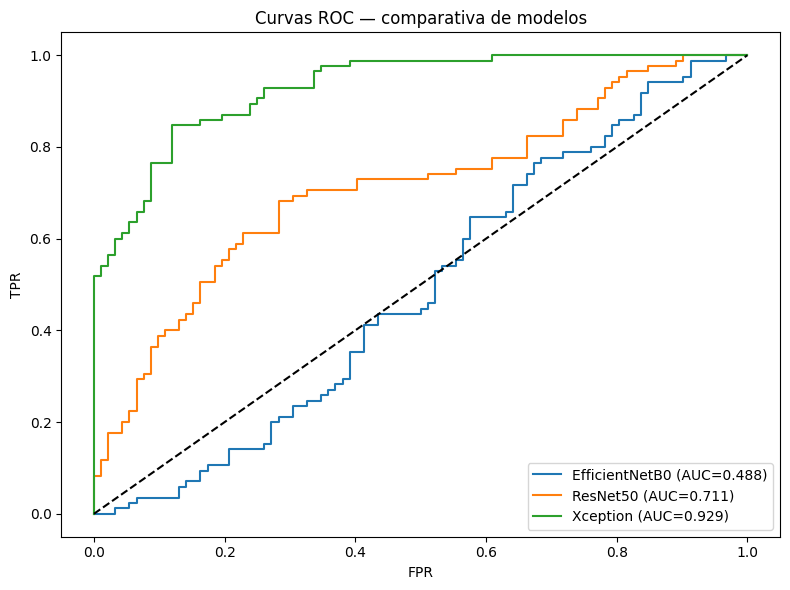

In [18]:
plt.figure(figsize=(8, 6))
for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, label=f"{r['name']} (AUC={r['auc']:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curvas ROC — comparativa de modelos')
plt.legend(); plt.tight_layout();


Mostramos tabla de resumen

In [19]:
summary = pd.DataFrame([{
    'Modelo':    r['name'],
    'Accuracy':  f"{r['acc']:.4f}",
    'AUC-ROC':   f"{r['auc']:.4f}",
} for r in results]).sort_values('AUC-ROC', ascending=False)

print('\n=== RESUMEN FINAL ===')
print(summary.to_string(index=False))

best = max(results, key=lambda r: r['auc'])
print(f'\n Mejor modelo: {best["name"]} (AUC={best["auc"]:.4f})')



=== RESUMEN FINAL ===
        Modelo Accuracy AUC-ROC
      Xception   0.8362  0.9293
      ResNet50   0.6497  0.7106
EfficientNetB0   0.5198  0.4884

 Mejor modelo: Xception (AUC=0.9293)


Guardamos el mejor modelo

In [20]:
best['model'].save(ROOT_PATH + f'/model/{best["name"]}_1.keras')
print(f'Modelo guardado en /model/{best["name"]}_1.keras')

Modelo guardado en /model/Xception_1.keras


# Aplicamos modelo a nuevas imágenes

In [24]:
from tensorflow import keras
model = keras.models.load_model(ROOT_PATH + '/model/Xception_1.keras')

# predict_image(best_model, 'ruta/imagen.jpg')

In [26]:
from PIL import Image

def preprocess_image(image_path, size=(IMAGE_WIDTH, IMAGE_HEIGHT)):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(size)
    arr = np.array(img).astype(np.float32) / 255.0
    return img, np.expand_dims(arr, axis=0)


def predict_and_show(model, image_path, size=(IMAGE_WIDTH, IMAGE_HEIGHT)):
    img, arr_input = preprocess_image(image_path, size)

    prob = model.predict(arr_input, verbose=0)[0][0]
    label = 'CARA' if prob >= 0.5 else 'SIN CARA'
    confianza = prob if prob >= 0.5 else 1 - prob
    color = 'green' if label == 'CARA' else 'red'

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f'{label}  —  confianza: {confianza:.2%}', color=color, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout();


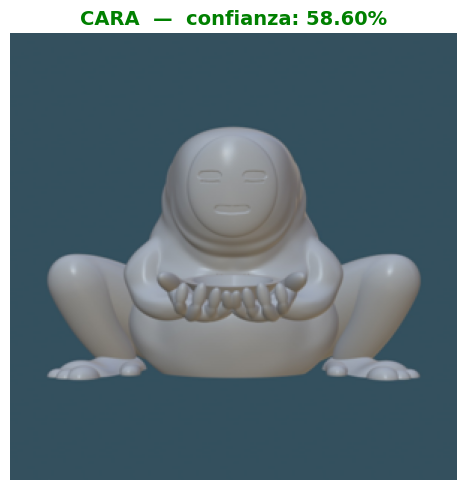

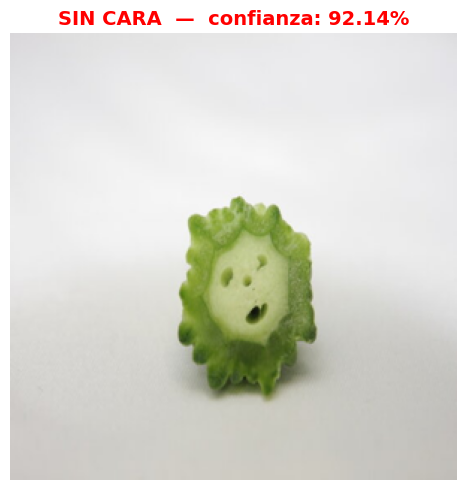

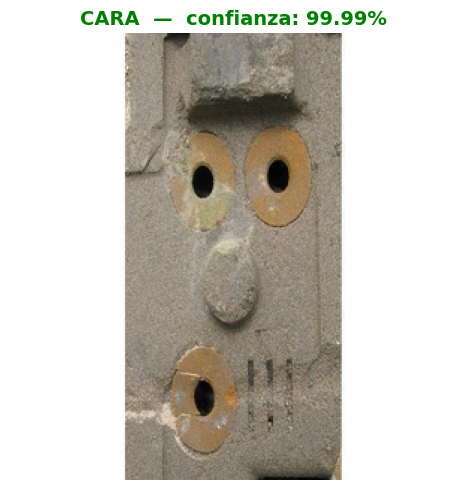

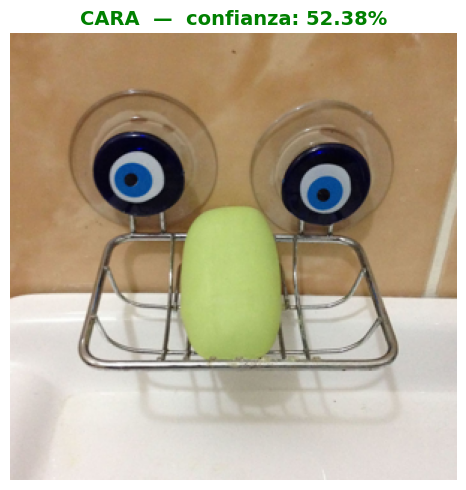

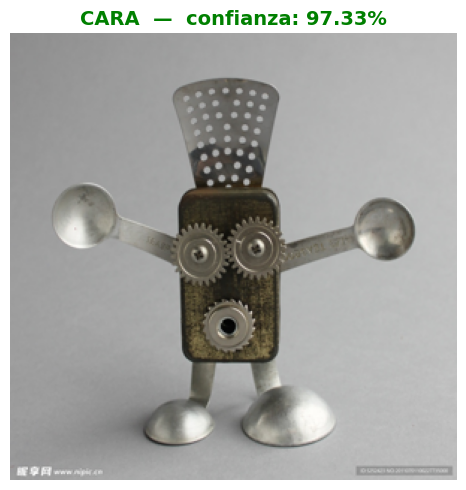

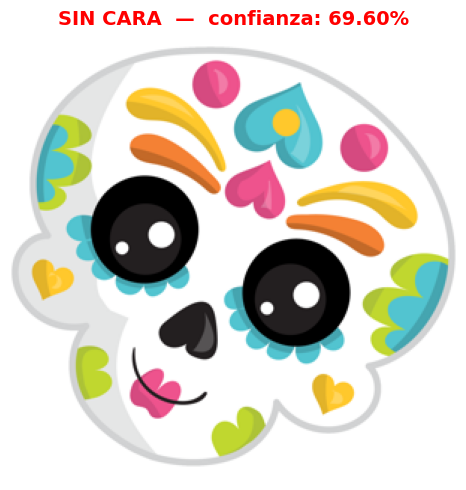

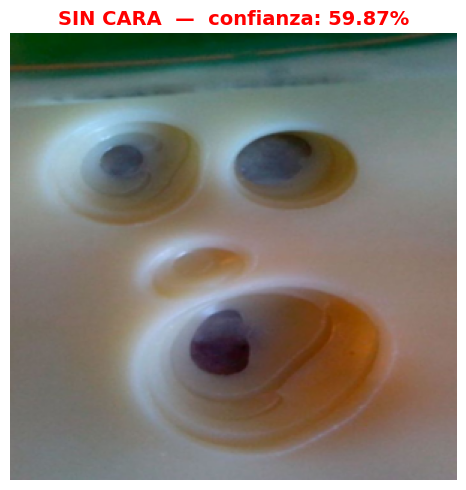

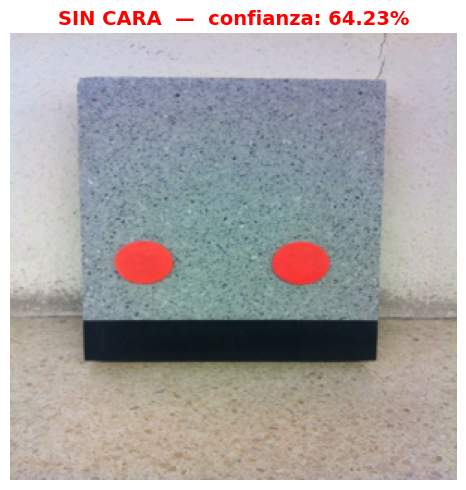

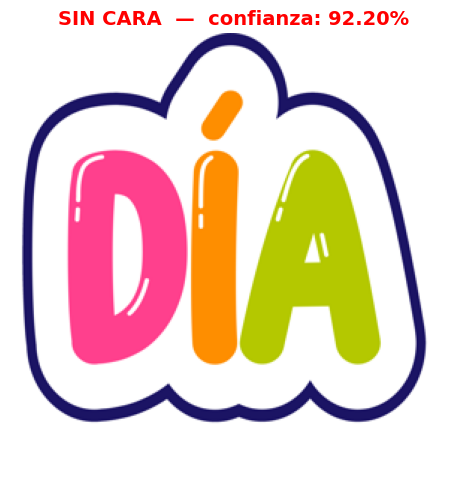

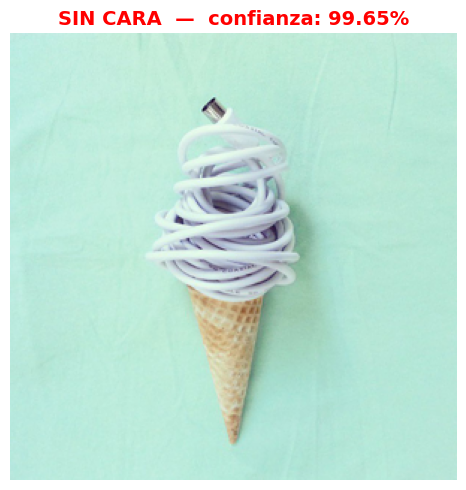

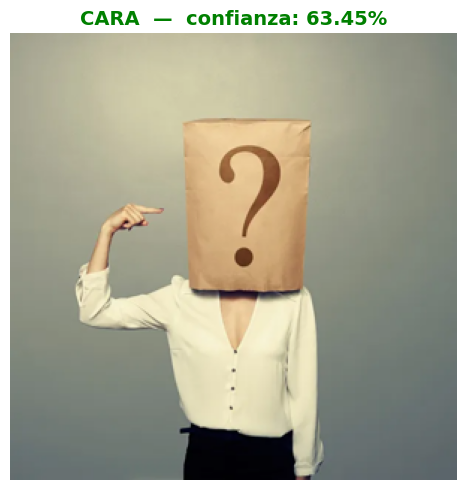

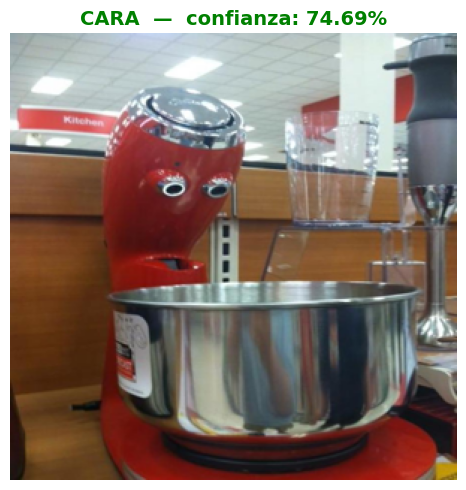

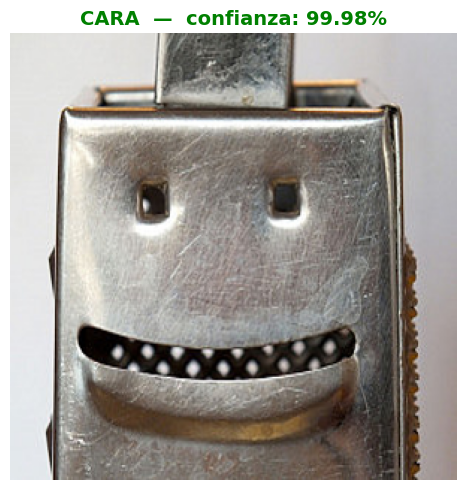

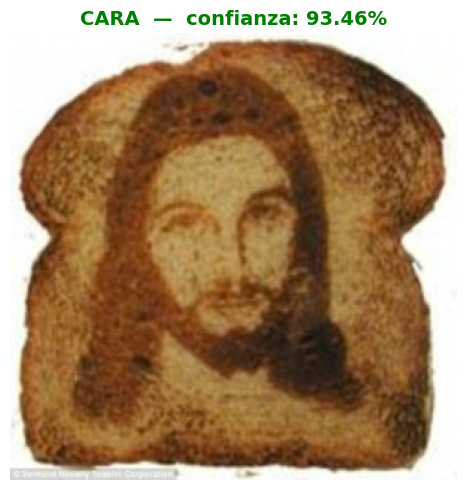

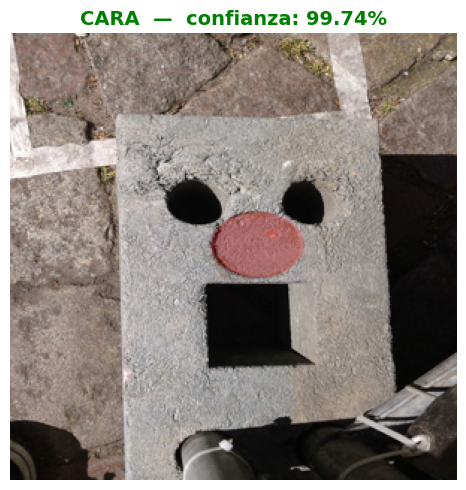

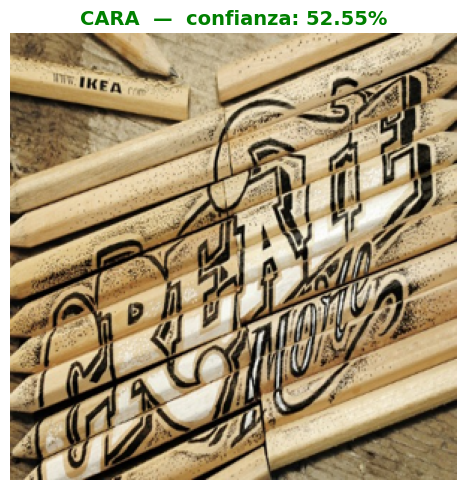

In [27]:
PREDICT_PATH = ROOT_PATH + '/data/predictions/'

for file in os.listdir(PREDICT_PATH):
    if file.lower().endswith(('.jpeg', '.jpg', '.png')):
        
        filename = f'{file}'
    # Para EfficientNetB0 o ResNet50 (224×224):
    # predict_and_show(best_model, 'ruta/imagen.jpg', size=(224, 224))
    # Para Xception (299×299):
    predict_and_show(model, PREDICT_PATH + filename, size=(299, 299))



# Modificaciones en los modelos

Vamos a probar varios cambios, como
- Escala de grises
- Ajustar el threshold
- Aumentar augmentations
- Fine‑tuning más profundo

### Resize de las imágenes

Tamaño imagen original: (299, 168)
Tamaño imagen reshape: (224, 224)


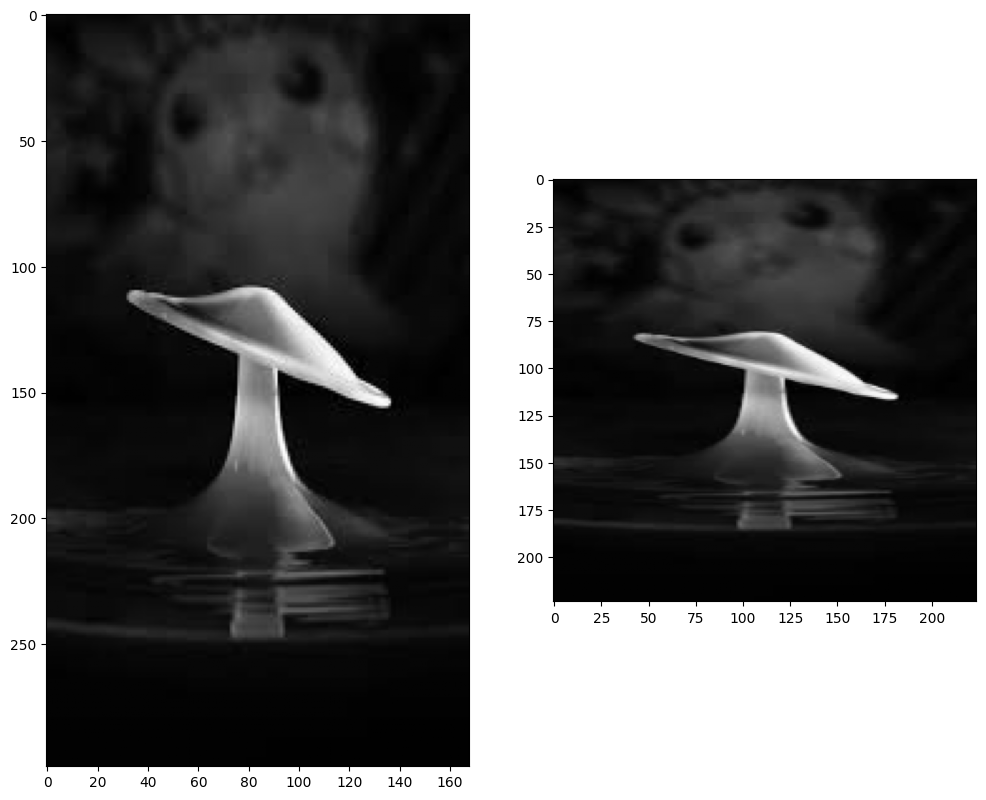

In [ ]:
from PIL import Image
import cv2

plt.figure(figsize=(12, 12))

sample = random.choice(filenames)
# sample = 'sin-cara_008.jpg'
ctgry = sample.split('_')[0] + '/'
img = Image.open(TRAIN_PATH + ctgry + sample)

# Convertir paleta con transparencia antes de pasar a gris
if img.mode in ('P', 'PA'):
    img = img.convert('RGBA')

img = img.convert('L')  # escala de grises
image = np.array(img)                           # → numpy array
imagesmall = cv2.resize(image, (IMAGE_WIDTH, IMAGE_HEIGHT))

print('Tamaño imagen original:', image.shape)
print('Tamaño imagen reshape:', imagesmall.shape)

# Original image
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')

# Resized image
plt.subplot(1, 2, 2)
plt.imshow(imagesmall, cmap='gray');

### Cargar datos

In [ ]:
# Función para cargar imágenes
from PIL import Image
import cv2

def read_data(ruta):
    X = []
    Y = []
    
    for c, cat in enumerate(CATEGORIES):
        path = ruta + cat + '/'
    
        # Iterar sobre todos los archivos que haya en path
        for file in os.listdir(path):
            if not file.lower().endswith(('.jpeg', '.jpg', '.png')):
                continue
            
            # Leer la imagen a color y aplicarle el resize
            img = Image.open(path + file)
            if img.mode in ('P', 'PA'):
                img = img.convert('RGBA')

            img = img.convert('L')
            img = img.resize((IMAGE_WIDTH, IMAGE_HEIGHT))
            
            arr = np.array(img).astype(np.float32) / 255.0  # (224, 224)
            arr = np.stack([arr]*3, axis=-1)                # (224, 224, 3)
            
            # Guardo en X
            X.append(arr)
            Y.append(c)

    return np.array(X), np.array(Y)

In [ ]:
X_train, y_train = read_data(TRAIN_PATH)
X_test, y_test = read_data(TEST_PATH)

print(X_train.shape)
print(X_test.shape)

(878, 224, 224, 3)
(190, 224, 224, 3)


### Normalizamos data

In [ ]:
print('Min:', np.min(X_train))
print('Max:', np.max(X_train))

# Solo si no está normalizado
if np.max(X_train) > 1.0:
    X_train = X_train / 255.0
    X_test = X_test / 255.0

    print('Min:', np.min(X_train))
    print('Max:', np.max(X_train))

Min: 0.0
Max: 1.0


### Preparamos data para modelo

In [ ]:
# Mezclamos imágenes para que no salgan en orden
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train, y_train, random_state=42)

Guardamos los arrays de numpy en un archivo `.npz`, de tal manera que luego sea más rápido importarlo.

In [ ]:
np.savez(ROOT_PATH + '/data/data_gray.npz',
        X_train = X_train,
        y_train = y_train,
        X_test = X_test,
        y_test = y_test)

Cargar data

In [ ]:
# Cargar data
data = np.load(ROOT_PATH + '/data/data_gray.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

### Construimos modelos

Definimos funciones

In [ ]:
from tensorflow.keras.applications import EfficientNetB0, ResNet50, Xception, InceptionV3, VGG16
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


# Función para construir modelos
def build_model(backbone_fn, input_shape=(224, 224, 3), weights='imagenet'):
    base = backbone_fn(include_top=False, weights=weights, input_shape=input_shape)
    base.trainable = False  # congelamos el backbone

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')  # binario
    ])

    model.compile(
        optimizer=optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# Función para entrenar los modelos
def train_model(model, X_train, y_train, epochs=30, batch_size=32):
    cb = [
        callbacks.EarlyStopping(patience=7, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ]
    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=1
    )
    return history


# Función para evaluar modelo
def evaluate_model(name, model, history, X_test, y_test):
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(classification_report(y_test, y_pred, target_names=['sin_cara', 'cara']))

    auc = roc_auc_score(y_test, y_prob)
    print(f'AUC-ROC: {auc:.4f}')

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].imshow(cm, cmap='Blues')
    axes[0].set_title(f'{name} — Matriz de confusión')
    axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14)
    axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
    axes[0].set_xticklabels(['sin_cara','cara']); axes[0].set_yticklabels(['sin_cara','cara'])

    # Curvas de aprendizaje
    axes[1].plot(history.history['accuracy'], label='Train acc')
    axes[1].plot(history.history['val_accuracy'], label='Val acc')
    axes[1].set_title(f'{name} — Curvas de aprendizaje')
    axes[1].set_xlabel('Época'); axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {'name': name, 'auc': auc, 'y_prob': y_prob,
            'acc': (y_pred == y_test).mean(), 'model': model}


# Función para predecir imagen nueva
def predict_image(model, image_path, size=(IMAGE_WIDTH, IMAGE_HEIGHT)):
    img = Image.open(image_path).convert('RGB').resize((IMAGE_WIDTH, IMAGE_HEIGHT))
    
    if img.mode in ('P', 'PA'):
        img = img.convert('RGBA')

    img_gray = img.convert('L').resize(size)
    arr = np.array(img_gray).astype(np.float32) / 255.0
    arr = np.stack([arr]*3, axis=-1)
    arr = np.expand_dims(arr, axis=0)
    
    prob = model.predict(arr, verbose=0)[0][0]
    label = 'cara' if prob >= 0.5 else 'sin_cara'

    plt.imshow(np.array(img))
    plt.title(f'{label}  (confianza: {prob:.2%})')
    plt.axis('off'); plt.show()

    return label, prob


# Función para comparar curvas ROC
def roc_curve(results, y_test):
    plt.figure(figsize=(8, 6))
    for r in results:
        fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
        plt.plot(fpr, tpr, label=f"{r['name']} (AUC={r['auc']:.3f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title('Curvas ROC — comparativa de modelos')
    plt.legend(); plt.tight_layout()
    


# Función para mostrar resultados
def resumen_resultados(results):
    summary = pd.DataFrame([{
        'Modelo':    r['name'],
        'Accuracy':  f"{r['acc']:.4f}",
        'AUC-ROC':   f"{r['auc']:.4f}",
    } for r in results]).sort_values('AUC-ROC', ascending=False)

    print('\n=== RESUMEN FINAL ===')
    print(summary.to_string(index=False))

    best = max(results, key=lambda r: r['auc'])
    print(f'\n Mejor modelo: {best["name"]} (AUC={best["auc"]:.4f})')

Entrenamos modelos 'EfficientNetB0', 'ResNet50' y 'Xception'


>>> Entrenando Xception...
Epoch 1/30
24/24 [==============================] - 58s 2s/step - loss: 0.7878 - accuracy: 0.5603 - val_loss: 0.6276 - val_accuracy: 0.7045 - lr: 1.0000e-04
Epoch 2/30
24/24 [==============================] - 48s 2s/step - loss: 0.5145 - accuracy: 0.7453 - val_loss: 0.5592 - val_accuracy: 0.8561 - lr: 1.0000e-04
Epoch 3/30
24/24 [==============================] - 46s 2s/step - loss: 0.3883 - accuracy: 0.8231 - val_loss: 0.5127 - val_accuracy: 0.8864 - lr: 1.0000e-04
Epoch 4/30
24/24 [==============================] - 46s 2s/step - loss: 0.3415 - accuracy: 0.8499 - val_loss: 0.4743 - val_accuracy: 0.8864 - lr: 1.0000e-04
Epoch 5/30
24/24 [==============================] - 46s 2s/step - loss: 0.2735 - accuracy: 0.8914 - val_loss: 0.4369 - val_accuracy: 0.8864 - lr: 1.0000e-04
Epoch 6/30
24/24 [==============================] - 46s 2s/step - loss: 0.2477 - accuracy: 0.9088 - val_loss: 0.4001 - val_accuracy: 0.9091 - lr: 1.0000e-04
Epoch 7/30
24/24 [============

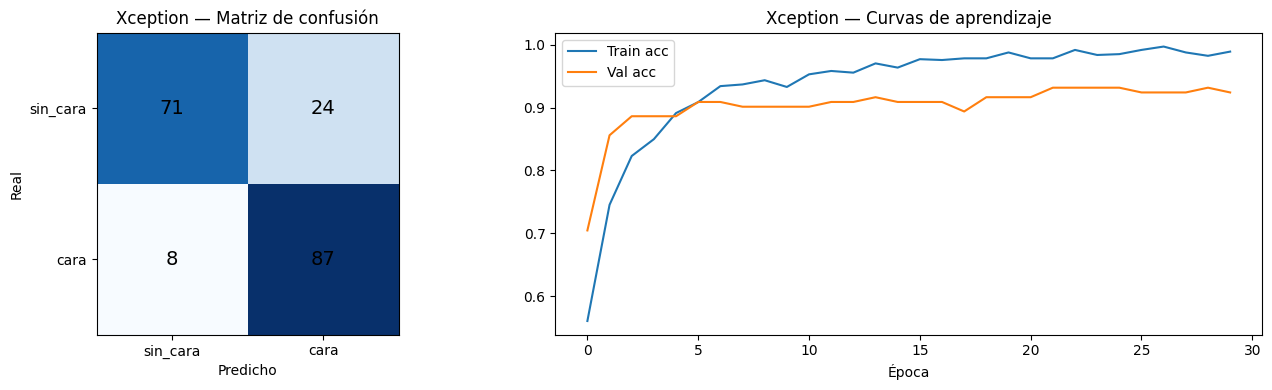

In [81]:
X_train_xception = tf.image.resize(X_train, [299, 299]).numpy()
X_test_xception  = tf.image.resize(X_test,  [299, 299]).numpy()

# De momento, probamos solo con 'Xception', que es el que mejor está funcionando
BACKBONES = {
    # 'EfficientNetB0': (EfficientNetB0, (224, 224, 3), X_train,         X_test),
    # 'ResNet50':       (ResNet50,       (224, 224, 3), X_train,         X_test),
    'Xception':       (Xception,       (299, 299, 3), X_train_xception, X_test_xception)
}

results = []

for name, (backbone_fn, input_shape, X_tr, X_te) in BACKBONES.items():
    print(f'\n>>> Entrenando {name}...')
    model   = build_model(backbone_fn, input_shape=input_shape)
    history = train_model(model, X_tr, y_train)
    result  = evaluate_model(name, model, history, X_te, y_test)
    results.append(result)

Comparamos curvas ROC

In [ ]:
roc_curve(results, y_test)

In [82]:
plt.figure(figsize=(8, 6))
for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, label=f"{r['name']} (AUC={r['auc']:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curvas ROC — comparativa de modelos')
plt.legend(); plt.tight_layout();


IndexError: invalid index to scalar variable.

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

Mostramos tabla de resumen

In [83]:
resumen_resultados(results)


=== RESUMEN FINAL ===
  Modelo Accuracy AUC-ROC
Xception   0.8316  0.9170

 Mejor modelo: Xception (AUC=0.9170)


In [52]:
summary = pd.DataFrame([{
    'Modelo':    r['name'],
    'Accuracy':  f"{r['acc']:.4f}",
    'AUC-ROC':   f"{r['auc']:.4f}",
} for r in results]).sort_values('AUC-ROC', ascending=False)

print('\n=== RESUMEN FINAL ===')
print(summary.to_string(index=False))

best = max(results, key=lambda r: r['auc'])
print(f'\n Mejor modelo: {best["name"]} (AUC={best["auc"]:.4f})')



=== RESUMEN FINAL ===
        Modelo Accuracy AUC-ROC
      Xception   0.7812  0.8958
      ResNet50   0.5625  0.8802
EfficientNetB0   0.2500  0.7448

 Mejor modelo: Xception (AUC=0.8958)


Guardamos el mejor modelo

In [84]:
best['model'].save(ROOT_PATH + f'/model/best{best["name"]}_2.keras')
print(f'Modelo guardado en /model/{best["name"]}_2.keras')

Modelo guardado en /model/Xception_2.keras


### Probamos modelo

In [55]:
from tensorflow import keras
model = keras.models.load_model(ROOT_PATH + '/model/bestXception_2.keras')

# predict_image(best_model, 'ruta/imagen.jpg')

In [ ]:
from PIL import Image

def preprocess_image(image_path, size=(IMAGE_WIDTH, IMAGE_HEIGHT)):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(size)
    arr = np.array(img).astype(np.float32) / 255.0
    return img, np.expand_dims(arr, axis=0)


def predict_and_show(model, image_path, size=(IMAGE_WIDTH, IMAGE_HEIGHT)):
    img, arr_input = preprocess_image(image_path, size)

    prob = model.predict(arr_input, verbose=0)[0][0]
    label = 'SIN CARA' if prob >= 0.5 else 'CARA'
    confianza = prob if prob >= 0.5 else 1 - prob
    color = 'green' if label == 'CARA' else 'red'

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f'{label}  —  confianza: {confianza:.2%}', color=color, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout();


In [ ]:
PREDICT_PATH = ROOT_PATH + '/data/predictions/'

for file in os.listdir(PREDICT_PATH):
    if file.lower().endswith(('.jpeg', '.jpg', '.png')):
        
        filename = f'{file}'
    # Para EfficientNetB0 o ResNet50 (224×224):
    # predict_and_show(best_model, 'ruta/imagen.jpg', size=(224, 224))
    # Para Xception (299×299):
    predict_and_show(model, PREDICT_PATH + filename, size=(299, 299))



### Ajustes del modelo

1. Threshold para minimizar falsos positivos

In [56]:
# Buscar el threshold óptimo
from sklearn.metrics import precision_recall_fscore_support

y_prob_xception = results[0]['y_prob']  # o results[i] si tienes varios modelos

thresholds = np.arange(0.50, 0.70, 0.01)
rows = []

for t in thresholds:
    y_pred_t = (y_prob_xception >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred_t, average='binary', zero_division=0)
    acc = (y_pred_t == y_test).mean()
    rows.append({'Threshold': f'{t:.2f}', 'Precision': f'{p:.4f}', 'Recall': f'{r:.4f}', 'F1': f'{f1:.4f}', 'Accuracy': f'{acc:.4f}'})

print(pd.DataFrame(rows).to_string(index=False))

Threshold Precision Recall     F1 Accuracy
     0.50    0.2500 1.0000 0.4000   0.2500
     0.51    0.2500 1.0000 0.4000   0.2500
     0.52    0.2500 1.0000 0.4000   0.2500
     0.53    0.2500 1.0000 0.4000   0.2500
     0.54    0.2500 1.0000 0.4000   0.2500
     0.55    0.2500 1.0000 0.4000   0.2500
     0.56    0.2500 1.0000 0.4000   0.2500
     0.57    0.2500 1.0000 0.4000   0.2500
     0.58    0.2500 1.0000 0.4000   0.2500
     0.59    0.2500 1.0000 0.4000   0.2500
     0.60    0.0000 0.0000 0.0000   0.7500
     0.61    0.0000 0.0000 0.0000   0.7500
     0.62    0.0000 0.0000 0.0000   0.7500
     0.63    0.0000 0.0000 0.0000   0.7500
     0.64    0.0000 0.0000 0.0000   0.7500
     0.65    0.0000 0.0000 0.0000   0.7500
     0.66    0.0000 0.0000 0.0000   0.7500
     0.67    0.0000 0.0000 0.0000   0.7500
     0.68    0.0000 0.0000 0.0000   0.7500
     0.69    0.0000 0.0000 0.0000   0.7500


# Modelo nuevo

Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada.

In [169]:
from tensorflow import keras


model = keras.Sequential([
    keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=IMAGE_SIZE),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2), # en cada epoch desactivamos un 20% de las neuronas. Así no overfiteamos, ya que no entrenamos la misma neurona con unas características concretas una y otra vez
    keras.layers.Dense(1, activation='sigmoid')  # 2 clases
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 222, 222, 64)      1792      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 111, 111, 64)      0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 109, 109, 128)     73856     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 54, 54, 128)       0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 373248)            0         
                                                                 
 dense_11 (Dense)            (None, 128)              

5. Reserva un 20% de los datos del entrenamiento para validar.

In [170]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

earlystop = EarlyStopping(patience=10)
mcheckpoint = ModelCheckpoint(ROOT_PATH + '/model/callback_model.keras')

In [171]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

history = model.fit(
    X_tr, y_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks = [earlystop, mcheckpoint], 
    validation_split = 0.2)

Epoch 1/100
21/21 [==============================] - 18s 804ms/step - loss: 2.6132 - accuracy: 0.5878 - val_loss: 0.6541 - val_accuracy: 0.6402
Epoch 2/100
21/21 [==============================] - 16s 781ms/step - loss: 0.6252 - accuracy: 0.6794 - val_loss: 0.6173 - val_accuracy: 0.6524
Epoch 3/100
21/21 [==============================] - 16s 773ms/step - loss: 0.5126 - accuracy: 0.7771 - val_loss: 0.6248 - val_accuracy: 0.6890
Epoch 4/100
21/21 [==============================] - 16s 788ms/step - loss: 0.2883 - accuracy: 0.8718 - val_loss: 0.7194 - val_accuracy: 0.7012
Epoch 5/100
21/21 [==============================] - 16s 762ms/step - loss: 0.1739 - accuracy: 0.9237 - val_loss: 0.6625 - val_accuracy: 0.7622
Epoch 6/100
21/21 [==============================] - 16s 763ms/step - loss: 0.1547 - accuracy: 0.9450 - val_loss: 0.8710 - val_accuracy: 0.6951
Epoch 7/100
21/21 [==============================] - 16s 781ms/step - loss: 0.0861 - accuracy: 0.9756 - val_loss: 1.4347 - val_accuracy:

6. Representa el objeto history.

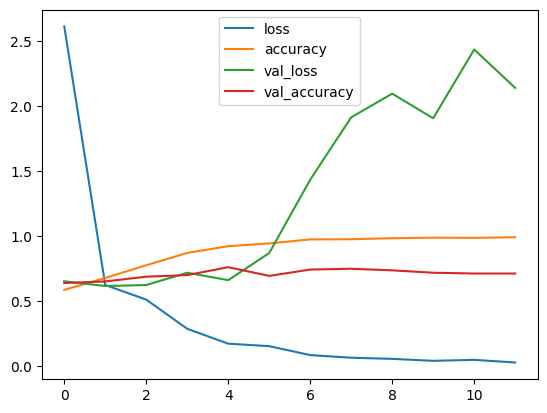

In [172]:
pd.DataFrame(history.history).plot();

7. Evalua el modelo con los datos de test.

In [173]:
loss, acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest accuracy: {acc:.4f}")

2/2 - 0s - loss: 3.6652 - accuracy: 0.4848 - 300ms/epoch - 150ms/step

Test accuracy: 0.4848
